# Figures 2B and C

Relationship between bounded efficiency (average score divided by threshold) and inequality (Gini index). Ovals highlight distinct coordination patterns emerging across sessions. 

Average score per round across all players, normalized by the corresponding capacity threshold.

In [73]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from scipy import stats
from collections import defaultdict

from Config.config import PATHS
from Utils.utils import GetMeasurements
from Utils.indices import AlternationIndex
from Classes.cognitive_model_agents import *

In [74]:
path_to_data = PATHS['human_data'] / 'processed_human_data.csv'
data = pd.read_csv(path_to_data)

gm = GetMeasurements(
    data=data, 
    measures=[
        'efficiency', 'bounded_efficiency', 'gini_index', 
        'entropy', 'min_entropy',
    ],
    T=20
)
gm.columns.append('threshold_bin')
df_measures = gm.get_measurements()

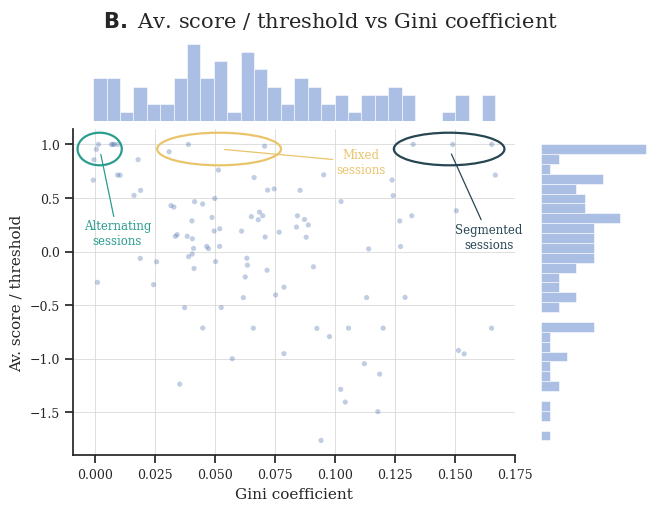

In [75]:
# Publication styling
sns.set_theme(style='ticks', font_scale=1.05)
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

rng = np.random.default_rng(0)
df_jitter = df_measures.copy()
n = df_jitter.shape[0]
sigma = 0.001
df_jitter['gini_index'] = df_jitter['gini_index'] + rng.normal(0, sigma, n)
df_jitter['bounded_efficiency'] = df_jitter['bounded_efficiency'] + rng.normal(0, sigma, n)

POINT_COLOR = '#4C72B0'
MARGINAL_COLOR = '#8FAADC'
CLUSTER_STYLES = {
    'Alternating': dict(xy=(0.06, 0.94), width=0.10, height=0.1, color='#2A9D8F',
                        label_xy=(0.1, 0.68)),
    'Mixed':       dict(xy=(0.33, 0.94), width=0.28, height=0.10, color='#E9C46A',
                        label_xy=(0.65, 0.9)),
    'Segmented':   dict(xy=(0.85, 0.94), width=0.25, height=0.10, color='#264653',
                        label_xy=(0.94, 0.67)),
}

fig = plt.figure(figsize=(6.5, 5.0), constrained_layout=True)
gs = fig.add_gridspec(
    2, 2, height_ratios=[1, 4], width_ratios=[4, 1],
    hspace=0.02, wspace=0.02,
)
ax_joint = fig.add_subplot(gs[1, 0])
ax_marg_x = fig.add_subplot(gs[0, 0], sharex=ax_joint)
ax_marg_y = fig.add_subplot(gs[1, 1], sharey=ax_joint)

sns.scatterplot(
    data=df_jitter,
    x='gini_index', y='bounded_efficiency',
    ax=ax_joint, color=POINT_COLOR,
    alpha=0.35, s=14, edgecolor='none',
    legend=False,
)
ax_joint.grid(True, color='0.85', linewidth=0.6, zorder=0)
ax_joint.set_axisbelow(True)

sns.histplot(
    data=df_jitter, x='gini_index', ax=ax_marg_x,
    bins=30, color=MARGINAL_COLOR, edgecolor='white', linewidth=0.4,
)
sns.histplot(
    data=df_jitter, y='bounded_efficiency', ax=ax_marg_y,
    bins=30, color=MARGINAL_COLOR, edgecolor='white', linewidth=0.4,
)

ax_marg_x.tick_params(axis='x', labelbottom=False, length=0)
ax_marg_x.set_xlabel('')
ax_marg_x.set_ylabel('')
ax_marg_x.tick_params(axis='y', labelleft=False, length=0)

ax_marg_y.tick_params(axis='y', labelleft=False, length=0)
ax_marg_y.set_ylabel('')
ax_marg_y.set_xlabel('')
ax_marg_y.tick_params(axis='x', labelbottom=False, length=0)

sns.despine(ax=ax_marg_x, bottom=True, left=True)
sns.despine(ax=ax_marg_y, bottom=True, left=True)
sns.despine(ax=ax_joint)

ax_joint.set_xlabel('Gini coefficient')
ax_joint.set_ylabel('Av. score / threshold')

for name, style in CLUSTER_STYLES.items():
    ax_joint.add_patch(patches.Ellipse(
        style['xy'], width=style['width'], height=style['height'],
        transform=ax_joint.transAxes,
        fill=False, edgecolor=style['color'],
        linewidth=1.6, linestyle='-', zorder=5,
    ))
    ax_joint.annotate(
        f'{name}\nsessions',
        xy=style['xy'], xycoords='axes fraction',
        xytext=style['label_xy'], textcoords='axes fraction',
        ha='center', va='center', fontsize=8.5, color=style['color'],
        arrowprops=dict(
            arrowstyle='-', color=style['color'],
            lw=0.9, shrinkA=0, shrinkB=4,
        ),
        zorder=6,
    )

fig.suptitle(r'$\bf{B.}$ Av. score / threshold vs Gini coefficient')
plt.show()


In [79]:
fig.savefig(PATHS['exploratory_figures'] / 'Fig2B.png', dpi=300, bbox_inches='tight')

In [77]:
path_to_data = PATHS['human_data'] / 'multi-player.csv'
data = pd.read_csv(path_to_data)
data['model'] = data.apply(lambda row: f"{row['num_players']}-{row['threshold']:.2f}-{row['group']}", axis=1)

gm = GetMeasurements(
    data=data, 
    measures=[
        'bounded_efficiency', 'entropy',
        'inequality', 'conditional_entropy', 'conditional_entropy_2nd_order', 'min_entropy'
    ],
    T=20
)
gm.columns.append('session')
gm.columns.append('approx_threshold')
print(gm.columns)
df = gm.get_measurements()
df['model'] = df.apply(lambda row: f"{row['num_players']}-{row['threshold']:.2f}-{row['group']}", axis=1)

ai = AlternationIndex.from_file(priority='mlp')
df['predicted_class'] = ai.classify(df)

df_best = df[df['bounded_efficiency'] > 0.87]
df_best = df_best[df_best['threshold'] < 1]

['model', 'treatment', 'threshold', 'num_players', 'group', 'session', 'approx_threshold']


Top 10 sessions:
            model  bounded_efficiency predicted_class
2-0.50-Grupo-0001            1.000000     Alternation
2-0.50-Grupo-0005            1.000000     Alternation
2-0.50-Grupo-0006            1.000000     Alternation
2-0.50-Grupo-0011            1.000000           Mixed
2-0.50-Grupo-0014            1.000000     Alternation
2-0.50-Grupo-0021            1.000000    Segmentation
        3-0.67-24            1.000000    Segmentation
        4-0.25-25            1.000000    Segmentation
        4-0.75-15            0.984127           Mixed
2-0.50-Grupo-0009            0.952381     Alternation


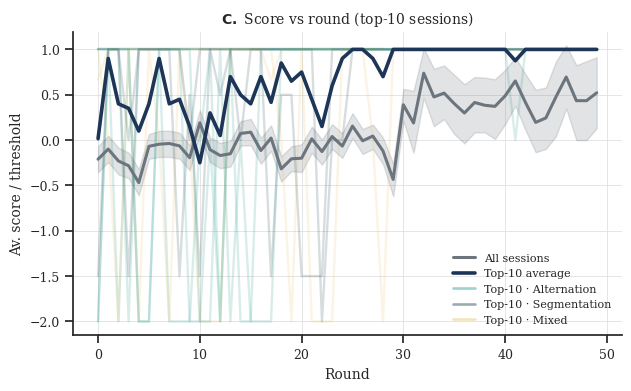

In [80]:
# Figure: panel C — faint individual top-10 session lines + their average
# Score divided by that session's threshold (session = group + threshold)
sns.set_theme(style='ticks', font_scale=1.05)
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

TYPE_LABELS = {
    'alternation': 'Alternation',
    'segmentation': 'Segmentation',
    'mixed': 'Mixed',
    'random': 'Random',
}
TYPE_COLORS = {
    'Alternation': '#2A9D8F',
    'Segmentation': '#264653',
    'Mixed': '#E9C46A',
    'Random': '#E76F51',
}
ALL_COLOR = '#6C757D'
TOP10_AVG_COLOR = '#1D3557'

# 10 highest-BE sessions among df_best (model encodes group+threshold)
df_top10 = (
    df_best
    .sort_values('bounded_efficiency', ascending=False)
    .drop_duplicates(subset=['model'])
    .head(10)
    .copy()
)
df_top10['predicted_class'] = (
    df_top10['predicted_class'].astype(str).str.lower().map(TYPE_LABELS)
    .fillna(df_top10['predicted_class'].astype(str).str.title())
)
session_order = df_top10['model'].tolist()
session_class = df_top10.set_index('model')['predicted_class'].to_dict()
print('Top 10 sessions:')
print(df_top10[['model', 'bounded_efficiency', 'predicted_class']].to_string(index=False))

# Normalize score by session threshold
data_plot = data[data['threshold'] > 0].copy()
data_plot['score_norm'] = data_plot['score'] / data_plot['threshold']

data_top10 = data_plot[data_plot['model'].isin(session_order)].copy()
top10_mean = (
    data_top10
    .groupby(['model', 'round'], as_index=False)['score_norm']
    .mean()
)
top10_mean['predicted_class'] = top10_mean['model'].map(session_class)
session_palette = {m: TYPE_COLORS.get(session_class[m], '#333333') for m in session_order}

# Average across the 10 sessions (equal weight per session)
top10_avg = (
    top10_mean
    .groupby('round', as_index=False)['score_norm']
    .mean()
)

fig_c, ax_c = plt.subplots(figsize=(6.2, 3.8), constrained_layout=True)

# Baseline: all sessions
sns.lineplot(
    x='round', y='score_norm',
    data=data_plot, ax=ax_c,
    color=ALL_COLOR, linewidth=2.2,
    errorbar=('ci', 95),
    label='All sessions',
    zorder=2,
)

# Very discrete individual session lines (keep class colors)
for m in session_order:
    sub = top10_mean[top10_mean['model'] == m]
    ax_c.plot(
        sub['round'], sub['score_norm'],
        color=session_palette[m],
        linewidth=1.7, alpha=0.18,
        solid_capstyle='round',
        zorder=1,
    )

# Average of the top-10 sessions (prominent)
ax_c.plot(
    top10_avg['round'], top10_avg['score_norm'],
    color=TOP10_AVG_COLOR, linewidth=2.6,
    label='Top-10 average',
    zorder=4,
)

# Legend: main curves + class color key (not every session)
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=ALL_COLOR, linewidth=2.2, label='All sessions'),
    Line2D([0], [0], color=TOP10_AVG_COLOR, linewidth=2.6, label='Top-10 average'),
]
for cls in ['Alternation', 'Segmentation', 'Mixed', 'Random']:
    if cls in set(session_class.values()):
        legend_handles.append(
            Line2D(
                [0], [0],
                color=TYPE_COLORS[cls], linewidth=1.9, alpha=0.45,
                label=f'Top-10 · {cls}',
            )
        )
ax_c.legend(handles=legend_handles, frameon=False, fontsize=8, loc='best')

ax_c.set_xlabel('Round')
ax_c.set_ylabel('Av. score / threshold')
ax_c.set_title(r'$\bf{C.}$ Score vs round (top-10 sessions)')
ax_c.grid(True, color='0.88', linewidth=0.6)
ax_c.set_axisbelow(True)
sns.despine(ax=ax_c)

plt.show()
fig_c.savefig(PATHS['exploratory_figures'] / 'Fig2C.png', dpi=300, bbox_inches='tight')
